# Unequal segment discretization: exploration for ZonedBorefields

This notebook explores whether **unequal (non-uniform) vertical segment lengths** can reduce the
number of segments needed per borehole (`nSeg`) for our zoned borefield application, while
keeping long-term (g-function) accuracy acceptable — as a first, pure-Python step before any
Modelica implementation work.

**Method**: Cimmino & Cook, *"pygfunction 2.2: New Features and Improvements in Accuracy and
Computational Efficiency"* (IGSHPA 2022). Segments expand geometrically from an
`end-length-ratio x1` at the two ends toward the middle (generalizing Eskilson's 1987 `γ=√2`
scheme), with the expansion factor solved from a closed-form polynomial. The paper's own
validation: **8 unequal segments (`x1=0.02`) are more accurate than 12 uniform segments**. This
is implemented in `pygfunction.utilities.segment_ratios(nSegments, end_length_ratio=0.02)` — we
use it directly rather than re-implementing the math.

**Borefield used**: our actual `Rectangle3Zones10Boreholes` configuration (3 zones, 10 boreholes
each, `hBor=100m`, `rBor=0.075m`, `dBor=1m`, `kSoi=2.5 W/m-K`), parsed directly from
`MBL_Example_ParallelZonesWithHorizontalPipes.mo` via `kappaGenerator.py`'s own
`parse_model_data`, so this notebook reflects the real geometry, not a toy example.

**Scope**: long-term (g-function, 0-20 years) accuracy only. Short-term (RC-network borehole
model) sensitivity to small/unequal segments is explicitly **not** tested here — a Python/
pygfunction proxy doesn't capture the real failure modes (adjacent-segment size-ratio jumps,
RC-network behavior with very different neighboring capacitances), so that's deferred until
after unequal segments are actually implemented in the Modelica model, where it can be tested
directly against `Buildings/Fluid/Geothermal/Borefields/Validation/Sandbox.mo` (the Beier et al.
2011 short-term validation case).


In [1]:
import sys
import time as tm

import matplotlib.pyplot as plt
import numpy as np
import pygfunction as gt

sys.path.insert(0, '.')
import kappaGenerator as kg
from pathlib import Path

# Load our actual borefield geometry directly from the model file kappaGenerator.py already
# knows how to parse - no need to duplicate/hardcode the configuration here. kappaGenerator.py's
# class-reference resolution now searches multiple package roots (default_search_roots()), so
# MODEL_PATH can point at any model that follows the ZonedBorefields convention (fixed-name
# nSegBor/tLoaAgg/nCel/conDat/soiDat), whether it lives in Buildings itself or in a deployment
# repo that references Buildings models - e.g. this could equally be repointed at
# 'ConferenceCollab_2026/ZonedBorefield_ParallelFlow_LKCC/LKCC_3_MixVolManifold_15Pipes.mo'.
MODEL_PATH = Path(
    '/home/jovyan/impact/local_projects/Impact_collab_sg-kul_modelicadeployment/'
    'ConferenceCollab_2026/ZonedBorefield_ParallelFlow_LKCC/'
    'MBL_Example_ParallelZonesWithHorizontalPipes.mo'
)
SEARCH_ROOTS = kg.default_search_roots()
data = kg.parse_model_data(MODEL_PATH, SEARCH_ROOTS)

h_bor = data['hBor']
d_bor = data['dBor']
r_bor = data['rBor']
a_soi = data['aSoi']
zones = data['zones']

boreholes = [
    gt.boreholes.Borehole(H=h_bor, D=d_bor, r_b=r_bor, x=b['x'], y=b['y'])
    for zone_boreholes in zones.values()
    for b in zone_boreholes
]

print(f"Borefield: {len(boreholes)} boreholes, hBor={h_bor}m, rBor={r_bor}m, dBor={d_bor}m, "
      f"aSoi={a_soi:.3e} m2/s")

# Log-spaced time array covering 0-20 years (g-functions are conventionally evaluated on a log
# time axis; the "0" end is represented by the earliest meaningful time, 1 hour).
TIME_S = np.geomspace(3600.0, 20 * 365 * 24 * 3600.0, 60)
T_S = h_bor**2 / (9 * a_soi)  # borefield characteristic time, for the ln(t/ts) x-axis

def compute_gfunc(n_seg, segment_ratios, boundary_condition='UBWT', approximate_fls=False):
    t0 = tm.perf_counter()
    gf = gt.gfunction.gFunction(
        boreholes, a_soi, time=TIME_S, method='equivalent', boundary_condition=boundary_condition,
        options={'nSegments': n_seg, 'segment_ratios': segment_ratios,
                  'approximate_FLS': approximate_fls},
    )
    elapsed = tm.perf_counter() - t0
    return gf.gFunc, elapsed


Borefield: 30 boreholes, hBor=100.0m, rBor=0.075m, dBor=1.0m, aSoi=1.157e-06 m2/s


## Part 1 — Long-term accuracy vs. segment count/distribution

Compare g-functions for:
- `nSeg=12`, **equal** segments (`segment_ratios=None`) — the traditional Cimmino & Bernier
  (2014) recommendation.
- `nSeg=8, 7, 6, 5, 4, 3`, **unequal** segments (`gt.utilities.segment_ratios(nSeg)`, default
  `end_length_ratio=0.02`).

`nSeg=8` unequal is used as the reference (per the paper's own validated recommendation, and the
value already used in `kappaGenerator.py`/the Step 2 validation). This directly answers the
original question: does going down to 6 (or fewer) unequal segments retain "enough" accuracy for
this application relative to paying for 8?


In [2]:
configs_part1 = [
    ('nSeg=12 equal', 12, None),
    ('nSeg=8 unequal (reference)', 8, gt.utilities.segment_ratios),
    ('nSeg=7 unequal', 7, gt.utilities.segment_ratios),
    ('nSeg=6 unequal', 6, gt.utilities.segment_ratios),
    ('nSeg=5 unequal', 5, gt.utilities.segment_ratios),
    ('nSeg=4 unequal', 4, gt.utilities.segment_ratios),
    ('nSeg=3 unequal', 3, gt.utilities.segment_ratios),
]

results_part1 = {}
for label, n_seg, seg_ratios in configs_part1:
    g, elapsed = compute_gfunc(n_seg, seg_ratios)
    results_part1[label] = g
    print(f"{label:28s} computed in {elapsed:.2f}s")

reference_label = 'nSeg=8 unequal (reference)'
g_ref = results_part1[reference_label]


nSeg=12 equal                computed in 0.38s


nSeg=8 unequal (reference)   computed in 0.35s


nSeg=7 unequal               computed in 0.30s


nSeg=6 unequal               computed in 0.27s


nSeg=5 unequal               computed in 0.25s


nSeg=4 unequal               computed in 0.21s
nSeg=3 unequal               computed in 0.19s


config                        mean % diff   max % diff
nSeg=12 equal                       0.363        2.120
nSeg=7 unequal                      0.010        0.092
nSeg=6 unequal                      0.046        0.400
nSeg=5 unequal                      0.091        0.738
nSeg=4 unequal                      0.420        4.536
nSeg=3 unequal                      0.446        4.969


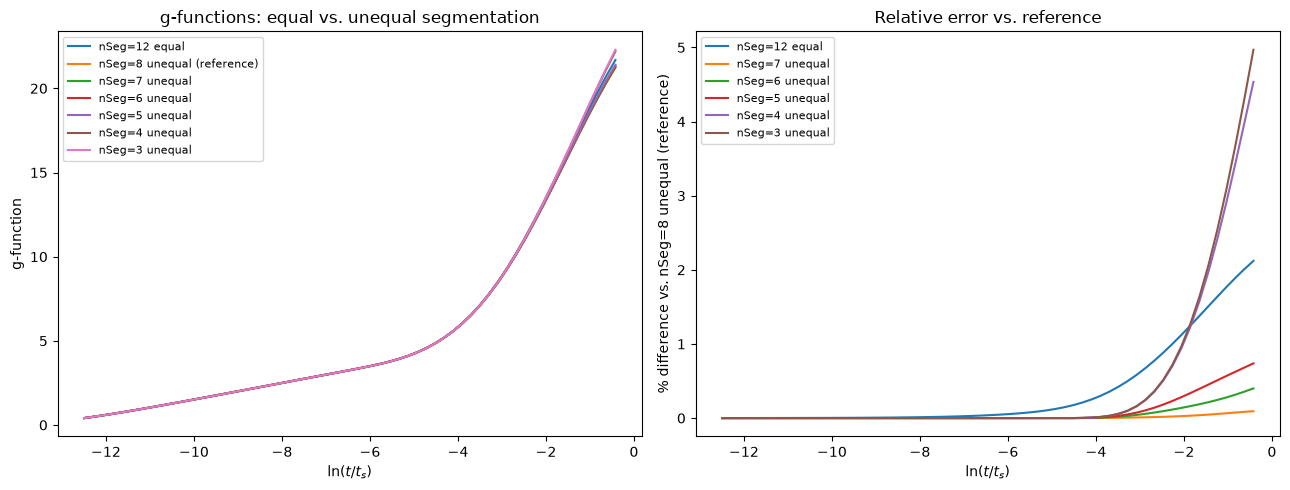

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

lnt_ts = np.log(TIME_S / T_S)
for label, g in results_part1.items():
    ax1.plot(lnt_ts, g, label=label)
ax1.set_xlabel(r'$\ln(t/t_s)$')
ax1.set_ylabel('g-function')
ax1.set_title('g-functions: equal vs. unequal segmentation')
ax1.legend(fontsize=8)

print(f"{'config':28s} {'mean % diff':>12s} {'max % diff':>12s}")
for label, g in results_part1.items():
    if label == reference_label:
        continue
    rel_diff = np.abs(g - g_ref) / np.abs(g_ref) * 100
    print(f"{label:28s} {rel_diff.mean():12.3f} {rel_diff.max():12.3f}")
    ax2.plot(lnt_ts, rel_diff, label=label)
ax2.set_xlabel(r'$\ln(t/t_s)$')
ax2.set_ylabel(f'% difference vs. {reference_label}')
ax2.set_title('Relative error vs. reference')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Part 2 — `end_length_ratio` sweep, long-term accuracy only

For `nSeg=3..8`, sweep `end_length_ratio` (0.02, 0.05, 0.1, 0.15, 0.2) and compare against the
same `nSeg=8`/`end_length_ratio=0.02` reference as Part 1.

Two things are reported per combination, not just the accuracy number: the **actual segment
length array** and the **max ratio between adjacent segments**. The reasoning (per discussion):
long-term accuracy loss is more likely driven by the *largest middle segment* being too coarse
than by the small end segments, and a large *jump* between adjacent segment sizes may itself be
a red flag worth knowing about before this ever reaches the Modelica short-term model. Both are
visible directly from the segment_ratios array, no simulation needed.


In [4]:
n_seg_range = [3, 4, 5, 6, 7, 8]
end_length_ratios = [0.02, 0.05, 0.10, 0.15, 0.20]

records = []
for n_seg in n_seg_range:
    for elr in end_length_ratios:
        ratios = gt.utilities.segment_ratios(n_seg, end_length_ratio=elr)
        g, elapsed = compute_gfunc(n_seg, ratios)
        rel_diff = np.abs(g - g_ref) / np.abs(g_ref) * 100
        max_adjacent_jump = np.max(ratios[1:] / ratios[:-1])  # ratio of consecutive segment sizes
        records.append({
            'nSeg': n_seg,
            'end_length_ratio': elr,
            'ratios': ratios,
            'max_segment_frac': ratios.max(),
            'min_segment_frac': ratios.min(),
            'max_adjacent_jump': max_adjacent_jump,
            'mean_pct_diff': rel_diff.mean(),
            'max_pct_diff': rel_diff.max(),
        })

print(f"{'nSeg':>4s} {'x1':>5s} {'max_seg':>8s} {'min_seg':>8s} {'max_jump':>9s} "
      f"{'mean%diff':>10s} {'max%diff':>9s}")
for r in records:
    print(f"{r['nSeg']:4d} {r['end_length_ratio']:5.2f} {r['max_segment_frac']:8.3f} "
          f"{r['min_segment_frac']:8.4f} {r['max_adjacent_jump']:9.2f} "
          f"{r['mean_pct_diff']:10.3f} {r['max_pct_diff']:9.3f}")


/home/jovyan/venvs/pygfunction/lib/python3.11/site-packages/pygfunction/utilities.py:209: UserWarning: A decreasing segment ratios discretization was found by utilities.segment_ratios(). Better accuracy is expected for increasing segment ratios. Consider decreasing the end-length-ratio such that end_length_ratio < 1 / nSegments.
  warnings.warn(


nSeg    x1  max_seg  min_seg  max_jump  mean%diff  max%diff
   3  0.02    0.960   0.0200     48.00      0.446     4.969
   3  0.05    0.900   0.0500     18.00      0.252     2.131
   3  0.10    0.800   0.1000      8.00      0.469     2.925
   3  0.15    0.700   0.1500      4.67      0.750     5.050
   3  0.20    0.600   0.2000      3.00      0.979     7.078
   4  0.02    0.480   0.0200     24.00      0.420     4.536
   4  0.05    0.450   0.0500      9.00      0.244     1.973
   4  0.10    0.400   0.1000      4.00      0.468     2.913
   4  0.15    0.350   0.1500      2.33      0.750     5.053
   4  0.20    0.300   0.2000      1.50      0.978     7.072
   5  0.02    0.720   0.0200      6.00      0.091     0.738
   5  0.05    0.564   0.0500      3.36      0.185     1.095
   5  0.10    0.400   0.1000      2.00      0.467     2.868
   5  0.15    0.286   0.1500      1.38      0.749     5.057
   5  0.20    0.200   0.2000      1.00      0.975     7.051
   6  0.02    0.392   0.0200      4.42  

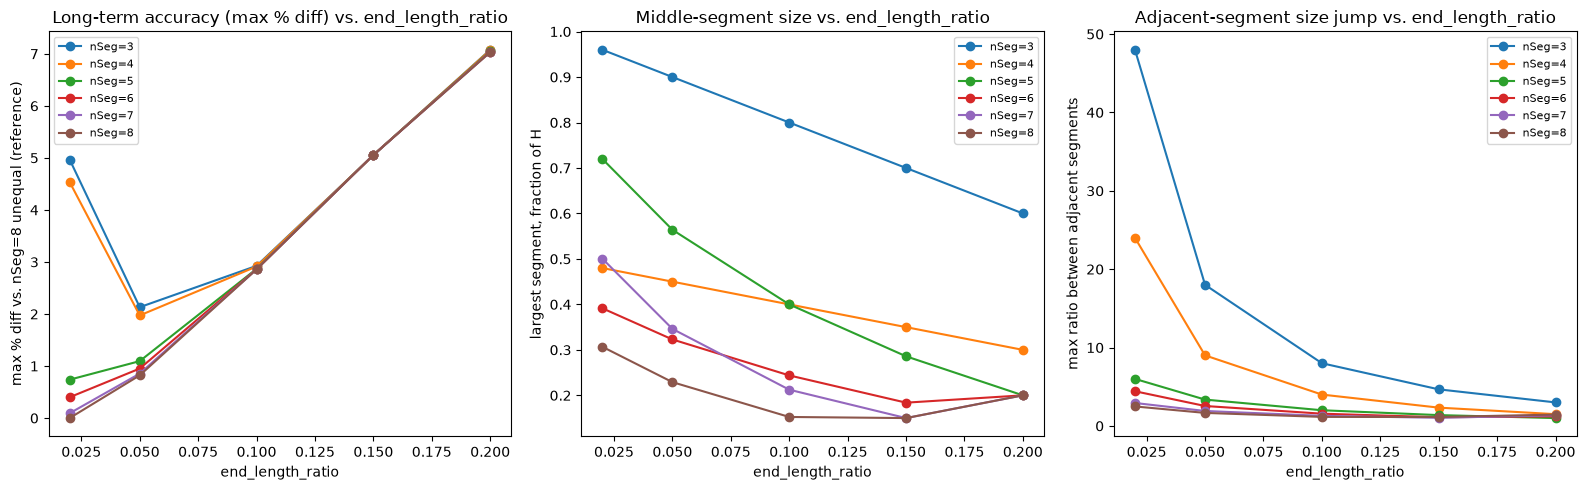

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for n_seg in n_seg_range:
    subset = [r for r in records if r['nSeg'] == n_seg]
    x = [r['end_length_ratio'] for r in subset]
    axes[0].plot(x, [r['max_pct_diff'] for r in subset], marker='o', label=f'nSeg={n_seg}')
    axes[1].plot(x, [r['max_segment_frac'] for r in subset], marker='o', label=f'nSeg={n_seg}')
    axes[2].plot(x, [r['max_adjacent_jump'] for r in subset], marker='o', label=f'nSeg={n_seg}')

axes[0].set_xlabel('end_length_ratio')
axes[0].set_ylabel(f'max % diff vs. {reference_label}')
axes[0].set_title('Long-term accuracy (max % diff) vs. end_length_ratio')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('end_length_ratio')
axes[1].set_ylabel('largest segment, fraction of H')
axes[1].set_title('Middle-segment size vs. end_length_ratio')
axes[1].legend(fontsize=8)

axes[2].set_xlabel('end_length_ratio')
axes[2].set_ylabel('max ratio between adjacent segments')
axes[2].set_title('Adjacent-segment size jump vs. end_length_ratio')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Observations

**Part 1 — segment count (fixed `end_length_ratio=0.02`), by max % diff (the number that
matters, not mean — worst case is what design margin needs to cover):**

| config | mean % diff | **max % diff** |
|---|---|---|
| nSeg=12 equal | 0.363% | 2.120% |
| nSeg=7 unequal | 0.010% | 0.092% |
| nSeg=6 unequal | 0.046% | 0.400% |
| nSeg=5 unequal | 0.091% | **0.738%** |
| nSeg=4 unequal | 0.420% | 4.536% |
| nSeg=3 unequal | 0.446% | 4.969% |

**Chosen: `nSeg=5` unequal.** Clearly better than `nSeg=12` equal (0.738% vs. 2.120% max, at
under half the segment count), and the drop to `nSeg=4` is a cliff (0.738% -> 4.536% max, a 6x
jump, occurring at year 20 / the longest simulated time). `nSeg=5` is the practical floor before
accuracy degrades sharply.

**Part 2 — `end_length_ratio` sweep for `nSeg=5`, by max % diff:**

| end_length_ratio | max_segment_frac | min_segment_frac | max_adjacent_jump | max % diff |
|---|---|---|---|---|
| 0.02 (default) | 0.720 | 0.0200 | 6.00 | 0.738% |
| **0.05 (chosen)** | 0.564 | 0.0500 | **3.36** | **1.095%** |
| 0.10 | 0.400 | 0.1000 | 2.00 | 2.868% |
| 0.15 | 0.286 | 0.1500 | 1.38 | 5.057% |
| 0.20 | 0.200 | 0.2000 | 1.00 | 7.051% |

**Chosen: `nSeg=5`, `end_length_ratio=0.05`** — max error 1.095% (still under a reasonable
threshold) in exchange for nearly *halving* the worst-case adjacent-segment size jump (6.00x ->
3.36x) and roughly doubling the smallest end segment (2% -> 5% of `H`, i.e. ~2m -> ~5m for our
`hBor=100m` case). This is the configuration to test against the short-term (RC-network)
borehole model first, per the plan: if it holds up there, it's the leading candidate; if not,
`nSeg=5`/`end_length_ratio=0.02` (max 0.738%, smaller end segments, larger jump) or a further
`end_length_ratio` increase are the fallbacks to try next, trading more long-term accuracy for
more short-term margin.

Going further than `end_length_ratio=0.05` costs long-term accuracy fast (`0.10` already nearly
triples the error to 2.87% max) for comparatively small further reduction in the adjacent-segment
jump — so `0.05` looks like the natural first step to test, not `0.10` or beyond.

**Caveat** (unchanged from before): for larger `end_length_ratio` combined with smaller `nSeg`
(not relevant to the `nSeg=5` column above, but visible in the full sweep table), `pygfunction`
warns that `end_length_ratio > 1/nSegments` and produces a degenerate discretization — those
specific combinations aren't reliable trend points.

## Outcome

`nSeg=5`, `end_length_ratio=0.05` was subsequently implemented and tested against the short-term
(RC-network) borehole model on two cases (an 18.3m validation case and a more realistic 150m
borefield) and held up there too (~0.1 K max difference vs. a 10-equal-segment reference in both
cases) — see the plan document
(`ConferenceCollab_2026/Resources/ClaudePlan/2026-0820_Plan_ZonedBorefields_KappaMatrix_ExternalComputation.md`)
for the full implementation writeup. It is now available (opt-in, not the library default) as
`Buildings.Fluid.Geothermal.ZonedBorefields.OneUTube`'s `nSeg=5` segmentation.

**Reusing this notebook for other models**: `kappaGenerator.py`'s class-reference resolution now
searches multiple package roots (`kappaGenerator.default_search_roots()`), so `MODEL_PATH` in the
setup cell can be repointed at any ZonedBorefields-convention model - in `Buildings` itself or in
a deployment repo such as `ConferenceCollab_2026` - to redo this same exploration for a different
borefield geometry (e.g.
`ConferenceCollab_2026/ZonedBorefield_ParallelFlow_LKCC/LKCC_3_MixVolManifold_15Pipes.mo`).
